# Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.colorbar as colorbar
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
from matplotlib.patches import Arc
from scipy.linalg import eigh_tridiagonal
from scipy.fft import fft, fftfreq
from scipy.optimize import minimize
import time
import warnings
from numba import njit
from numba import prange
warnings.filterwarnings("ignore")

In [2]:
def transform(beta_signal, C):                                                      # Contains all the information of the orthogonal transformation
  N = len(beta_signal)
  eigenvalues, S = eigh_tridiagonal(beta_signal, C, check_finite=False, tol=1e-5, lapack_driver='stebz')            # Numerical eigenvalues and eigenvectors
  eigenvalues = eigenvalues[::-1]                                                   # Ordering eigenvalues from largest to smalesst
  St = S[:, ::-1]                                                                   # Ordering eigenvectors according to eigenvalues
  S = St.T
  eigenvalues = eigenvalues.reshape((1, len(eigenvalues)))
  Lambda = eigenvalues + eigenvalues.T
  return S, Lambda, eigenvalues

def eta(N=None, profile_type='all', l=None, pump=None, default=True):               # Unit vector eta
  if default:
    if profile_type == 'all':
      return [1 for i in range(N)] / np.sqrt(N)                                     # Homogeneous injection
    elif profile_type == 'one':                                                     # Injection in the waveguide number "l"
      if l is None:
        l = int((N + 1)/2)                                                          # Injection in the center if waveguide number is not specified
      return [1 if l - 1 == i else 0 for i in range(N)]
  else:
      return [j for j in pump] / np.sqrt(np.sum(np.abs(pump) ** 2))

def i2s(X_i, transf_data):                                                          # transforms from individual-mode basis to supermode basis
  S = transf_data[0]
  if isinstance(X_i, tuple):
    return tuple(S @ x_i @ S.transpose() for x_i in X_i)
  elif isinstance(X_i, np.ndarray):
    return S @ X_i @ S.transpose()

def s2i(X_s, transf_data):                                                          # transforms from supermode basis to individual-mode basis
  S = transf_data[0]
  if isinstance(X_s, tuple):
    return tuple(S.transpose() @ x_s @ S for x_s in X_s)
  elif isinstance(X_s, np.ndarray):
    return S.transpose() @ X_s @ S

def JSA(Q):                                                                         # calculates joint-spatial amplitude
  N = Q.shape[-1]
  return 2 ** (1 - np.eye(N) / 2) * Q

@njit(parallel=True)
def Q_s_parallel(z_vals, g, alpha, pump_data, transf_data, beta_pump):
    S, Lambda, _ = transf_data
    N = S.shape[1]
    P = len(z_vals)
    Q_nm = np.zeros((P, N, N), dtype=np.complex128)

    if P > 1:
        # Parallelize over z-values
        for p in prange(P):
            z = z_vals[p]
            temp = np.zeros((N, N), dtype=np.complex128)
            for j in range(N):
                S_n = S[:, j]
                P_nm = pump_data[j] * np.outer(S_n, S_n)
                beta = beta_pump[j]
                phase = (Lambda + beta) * z / 2
                arg = (Lambda - beta) * z / (2 * np.pi)
                T_nm = np.exp(1j * phase) * np.sinc(arg)
                temp += P_nm * T_nm
            Q_nm[p] = 1j * z * g * alpha * temp
    else:
        # Parallelize over j if only one z
        z = z_vals[0]
        contribs = np.zeros((N, N, N), dtype=np.complex128)
        for j in prange(N):
            S_n = S[:, j]
            P_nm = pump_data[j] * np.outer(S_n, S_n)
            beta = beta_pump[j]
            phase = (Lambda + beta) * z / 2
            arg = (Lambda - beta) * z / (2 * np.pi)
            T_nm = np.exp(1j * phase) * np.sinc(arg)
            contribs[j] = P_nm * T_nm

        temp = np.zeros((N, N), dtype=np.complex128)
        for j in range(N):
            temp += contribs[j]

        Q_nm[0] = 1j * z * g * alpha * temp

    return Q_nm

def corr(X):
  N = X.shape[-1]                                                                     # Correlation matrix
  norm =  np.sum(2 ** (np.eye(N) - 1) * np.abs(X) ** 2, axis=(-1, -2), keepdims=True) # Norm of state
  return np.abs(X) ** 2 / norm

def n(X):
  N = X.shape[-1]                                                                     # Normalized expectation value of number operator
  n = np.sum((1 + np.eye(N)) * np.abs(X) ** 2, axis=-1)
  return n / np.sum(n, axis=-1, keepdims=True)

def pr(prob):
  prob_no_nans = np.where(np.isnan(prob), 0, prob)                                    # Participation ratio
  return 1 / np.sum(prob_no_nans ** 2, axis=-1)

def st_dev(dist):                                                                     # Standard deviation
  if len(dist.shape) == 2:
    points, N = dist.shape
    M = np.tile(np.linspace(1, N, N), (points, 1))                                    # Waveguide numbers
  else:
    N = len(dist)
    M = np.linspace(1, N, N)
  return np.sqrt(np.sum(M ** 2 * dist, axis=-1) - np.sum(M * dist, axis=-1) ** 2)

def simulate(N, C0, g, alpha, L, pump_data, transf_data, beta_pump, basis='individual', calc_extra=False, points=200, add_matrices=False):
  if points > 1:
    z = np.linspace(0, L, points)#[:, None, None] * np.ones((N, N))
  else:
    z = [L]
  sol = Q_s_parallel(z, g, alpha, pump_data, transf_data, beta_pump)
  if basis == 'individual':
    sol = s2i(sol, transf_data)
  if add_matrices:
    Q = sol[0]
  else:
    Q = sol
  K = JSA(Q)
  prob = n(K)
  corr_map = corr(K)
  part_ratio = pr(prob)
  std = st_dev(prob)                                                              # Standard deviation
  if points == 1:
    std = st_dev(prob)
    return std
  elif calc_extra and basis == 'individual':
    std_der = np.gradient(np.log(std), np.log(C0*z), edge_order=2)         # Logarithmic derivative of standard deviaton
    return prob, corr_map, std, std_der
  elif add_matrices:                                                                # Returns matrix decomposition of Hadamard product
    return prob, corr_map, K, *sol[1:]
  else:
    return prob, corr_map

def linear(N, C0, L, input_data, transf_data, basis='individual', calc_extra=False, points=200):
  z = np.linspace(0, L, points)[:, None, None] * np.ones((N, N))
  if points > 1:
    z = np.linspace(0, L, points)[:, None, None] * np.ones((N, N))
  else:
    z = L
  _, _, eigenvalues = transf_data
  exp = np.exp(1j * eigenvalues * z)
  U_s = np.where(np.broadcast_to(np.eye(N), (points, N, N)), exp, 0)
  if points == 1:
    U_s = U_s.squeeze()
  U_i = s2i(U_s, transf_data)
  P = 2 ** (-np.eye(N) / 2) * input_data
  Q_i = U_i @ P @ U_i
  K_i = JSA(Q_i)
  prob = n(K_i)
  corr_map = corr(K_i)
  part_ratio = pr(prob)
  std = st_dev(prob)

  if points == 1:
    return std, part_ratio
  elif calc_extra:
    std_der = np.gradient(np.log(std), np.log(C0*z[:, 0, 0]), edge_order=2)
    return prob, corr_map, std, std_der, part_ratio
  else:
    return prob

def create_target(N, indexes, vanishing=False):                                     # Creates target correlation matrix for optimization
  all_idx = [(i, j) for i in range(N) for j in range(N)]
  nonzero_idx = indexes
  zero_idx = [i for i in indexes if i not in nonzero_coeffs]
  if vanishing:
    nonzero_idx, zero_idx = zero_idx, nonzero_idx

  target = np.zeros((N, N))
  for pair in nonzero_idx:
    target[pair] = 1
  _ = np.sum(2 ** (np.eye(N) - 1) * target)

  return target / _

def merit(var, target, transf_data, N, basis='individual'):                         # Merit function for optimization
  N = int((len(var) - 1) / 2 )
  z = var[0]
  pump = var[1:]
  pump_data = eta(pump=[abs(pump[2 * i]) * np.exp(1j * pump[2 * i + 1]) for i in range(N)], default=False)
  Q = Q_s(z, C0=1, g=1, alpha=1, pump_data=pump_data, transf_data=transf_data)
  if basis == 'individual':
    Q = s2i(Q, transf_data)
  K = JSA(Q)
  corr_m = corr(K)

  merit = np.sum((corr_m - target) ** 2)
  return merit

def similarity(target, optimization):
  return np.sum(np.sqrt(target * optimization)) ** 2 / (np.sum(target) * np.sum(optimization))


def disorder_data(N, C0, g, alpha, beta_s, L, f_0, max_c, max_b, c_points, b_points, z_points, n_runs=200, max_kappa=1, pump_waveguide=None):
  betas_signal_0 = beta_s * np.ones(N)
  if pump_waveguide is None:
    pump_waveguide = int((N + 1) / 2)
  pump_data = np.zeros(N)
  pump_data[pump_waveguide - 1] = 1
  if c_points == 6 and b_points == 1:
    c_list = [0, 0.1, 0.2, 0.4, 0.6, 0.8]
    b_list = [0]
  elif c_points == 1 and b_points == 6:
    c_list = [0]
    b_list = [0, 0.1, 0.2, 0.4, 0.6, 0.8]
  else:
    c_list = np.linspace(0, max_kappa, c_points)
    b_list = np.linspace(0, max_kappa, b_points)

  z = np.linspace(0, L, z_points)
  std_der_av = np.zeros((c_points, b_points, z_points))
  if z_points > 1:
    std_av = np.zeros((c_points, b_points, z_points))
  else:
    std_av = np.zeros((c_points, b_points))

  rand_kappa = lambda kappa, N: kappa * (2 * np.random.rand(N) - 1)

  time_diag = 0
  time_sim = 0
  for i, kappa_c in enumerate(c_list):
    for k, kappa_b in enumerate(b_list):
      for j in range(n_runs):
        t0 = time.time()
        betas_signal = betas_signal_0 + rand_kappa(kappa_b, N) * max_b
        C = C0 * f_0 + rand_kappa(kappa_c, N - 1) * max_c
        transf_data = transform(betas_signal, C)
        betas_pump = 2 * betas_signal
        time_diag += time.time() - t0
        #if j > 0:
        #  std_slast = std_av[i, k] / j
        t0 = time.time()
        data_ij = simulate(N, C0, g, alpha, L, pump_data, transf_data, betas_pump, calc_extra=True, points=z_points)
        if z_points == 1:
          std_av[i, k] += data_ij
        else:
          std_av[i, k] += data_ij[2]
          std_der_av[i, k] += data_ij[3]

        time_sim += time.time() - t0

        if (kappa_c == 0 and kappa_b == 0):
          break
        #if j > 0:
        #  error = 100 * np.abs(std_last - std_slast) / std_slast
        #  if np.nanmax(error) < max_error:
        #    print(f'For kappa coupling = {kappa_c:.1f} and kappa beta = {kappa_b:.1f}:')
        #    print('Terminated after', j + 1, 'runs and reaching an error of', round(np.nanmax(error), 3), '%')
        #    break

      #print(f'For kappa coupling = {kappa_c:.1f} and kappa beta = {kappa_b:.1f}:')
      #print('Terminated after', j + 1, 'runs and reaching an error of', round(np.nanmax(error), 3), '%')
      if kappa_c == 0 and kappa_b == 0:
        continue
      else:
        std_av[i, k] = std_av[i, k] / n_runs
        std_der_av[i, k] = std_der_av[i, k] / n_runs
  if True:
      print('Diagonalization time =', time_diag)
      print('Simulation time =', time_sim)
      print('Total time =', time_diag + time_sim)
  if z_points > 1:
    return std_av.squeeze(), std_der_av.squeeze()
  else:
    return std_av.squeeze()

# Main

## Effect of disorder on propagation

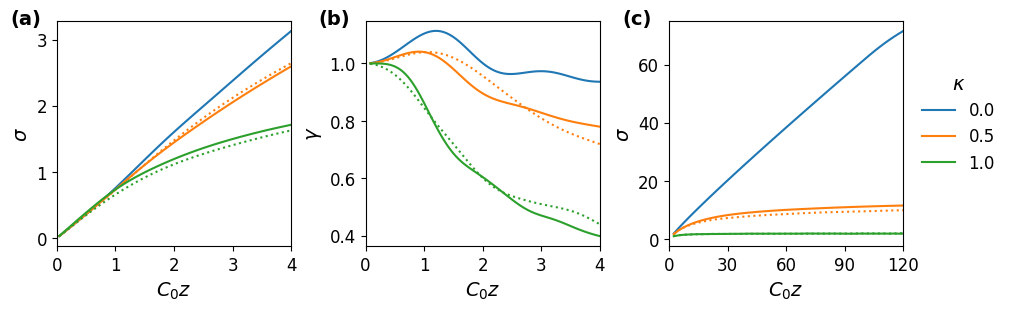

In [6]:
pump = 'center'
C0 = 250
if pump == 'center':
    L = 4 / C0
    ticks = [0, 1, 2, 3, 4]
else:
    L = 4.8 / C0
    ticks = [0, 1.2, 2.4, 3.6, 4.8]
data = np.load(f'data/{pump}_N=51,L={L*C0:.0f}C0.npy')
std_data = data[0]
std_der_data = data[1]

std_off = np.load('data/center_c_N=401,L=120C0.npy')
std_diag = np.load('data/center_b_N=401,L=120C0.npy')
std_data_off = std_off[0]
std_data_diag = std_diag[0]

font_size = 14
tick_size = 12

points = 100
z = np.linspace(0, L, points)
z_l = np.linspace(0, 120 / C0, 50)

# Create figure with constrained layout
fig = plt.figure(constrained_layout=True, figsize=(10, 3))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1])#, wspace=0.5)

# Axes
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax02 = fig.add_subplot(gs[0, 2])
axes = [ax00, ax01, ax02]

# Plots
idx = [0, 10, 20]
kappa_list = [0.0, 0.5, 1.0]
colors = ['C0', 'C1', 'C2']

for color in colors:
    ax02.plot([], [], color)

for i, kappa, color in zip(idx, kappa_list, colors):
    ax00.plot(C0 * z, std_data[i, 0], color=color)
    ax01.plot(C0 * z, std_der_data[i, 0], color=color)
    if i != 0:
        ax00.plot(C0 * z, std_data[0, i], color=color, ls=':')
        ax01.plot(C0 * z, std_der_data[0, i], color=color, ls=':')
    else:
        pass

idx = [0, 5, 10]
for i, kappa, color in zip(idx, kappa_list, colors):
    ax02.plot(C0 * z_l, std_data_off[i], color=color)
    if i != 0:
        ax02.plot(C0 * z_l, std_data_diag[i], color=color, ls=':')
    else:
        pass

# Axes formatting
for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_size)
ax00.set_xlim(C0 * z[0], C0 * z[-1])
ax01.set_xlim(C0 * z[0], C0 * z[-1])
ax02.set_xlim(C0 * z_l[0], C0 * z_l[-1])
ax00.set_xlabel('$C_0 z$', fontsize=font_size)
ax01.set_xlabel('$C_0 z$', fontsize=font_size)
ax02.set_xlabel('$C_0 z$', fontsize=font_size)
ticks = [0, 1, 2, 3, 4]
ax00.set_xticks(ticks, ticks)
ax01.set_xticks(ticks, ticks)
ticks = [0, 30, 60, 90, 120]
ax02.set_xticks(ticks, ticks)

ax00.set_ylabel('$\\sigma$', fontsize=font_size)
ax01.set_ylabel('$\\gamma$', fontsize=font_size)
ax02.set_ylabel('$\\sigma$', fontsize=font_size)

letters = ['(a)', '(b)', '(c)', '(d)']
for ax, letter in zip(axes, letters):
  ax.text(-0.2, 1.05, letter, transform=ax.transAxes, fontsize=font_size, fontweight='bold', va='top')

ax02.legend(kappa_list, title='$\kappa$', frameon=False, fontsize=tick_size, title_fontsize=font_size, loc=(1.05, 0.3))

plt.show()

### Presence of superballistic regime

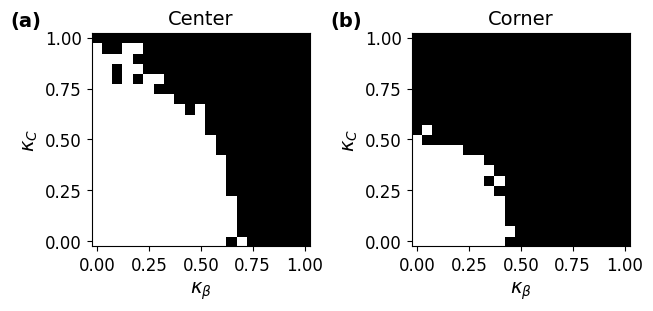

In [11]:
std_der_data_center = np.load(f'data/center_N=51,L=4C0.npy')[1]
std_der_data_corner = np.load(f'data/corner_N=51,L=5C0.npy')[1]
data = [std_der_data_center, std_der_data_corner]

max_exp = np.zeros((2, std_der_data.shape[0], std_der_data.shape[1]))
max_z = np.zeros((2, std_der_data.shape[0], std_der_data.shape[1]))
for k, std_der_data in enumerate(data):
    kappa = np.linspace(0, 1, std_der_data.shape[0])

    for i in range (std_der_data.shape[0]):
      for j in range (std_der_data.shape[1]):
        idx = np.nanargmax(std_der_data[i, j])
        max_exp[k, i, j] = std_der_data[i, j, idx]
        max_z[k, i, j] = C0 * z[idx]

gamma_th = 1e-3
z_th = 1e-1
mask = (max_exp - 1 > gamma_th) #& (max_z > z_th)

font_size = 14
tick_size = 12

C0 = 250
points = 100
L = 4 / C0
z = np.linspace(0, L, points)

#fig = plt.figure(constrained_layout=True, figsize=(6.4, 6.4/2))
#gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.05], wspace=0.05)
fig, ax  = plt.subplots(1, 2, constrained_layout=True, figsize=(6.4, 3))
ax00, ax01 = ax
axes = [ax00, ax01]
# Axes
#cax0 = fig.add_subplot(gs[0, 2])
#ax00 = fig.add_subplot(gs[0, 0])
#ax01 = fig.add_subplot(gs[0, 1])
#caxes = [cax0]

pc0 = ax00.pcolor(mask[0], cmap='gray')#, vmax=vmax0)
pc1 = ax01.pcolor(mask[1], cmap='gray')#, vmax=vmax1)

for ax in axes:
  ax.set_xlabel(r'$\kappa_\beta$', fontsize=font_size)
  ax.set_ylabel(r'$\kappa_C$', fontsize=font_size)
  ax.set_xticks(np.arange(1, len(kappa) + 1, 5) - 0.5, ['0.00', '0.25', '0.50', '0.75', '1.00'], fontsize=tick_size)
  ax.set_yticks(np.arange(1, len(kappa) + 1, 5) - 0.5, ['0.00', '0.25', '0.50', '0.75', '1.00'], fontsize=tick_size)

#cbar0 = fig.colorbar(pc0, cax=cax0, orientation='vertical')
#cbar0.ax.tick_params(labelsize=tick_size)
#cbar0.set_ticks([0, 1])
#cbar0.set_ticklabels(['No transition', 'Transition'])
#cbar0.ax.set_ylabel('$\\gamma_\\mathrm{{max}}$', rotation=0, labelpad=25, fontsize=font_size)

ax00.set_title('Center', fontsize=font_size)
ax01.set_title('Corner', fontsize=font_size)

letters = ['(a)', '(b)']
for ax, letter in zip(axes, letters):
  ax.text(-0.375, 1.1, letter, transform=ax.transAxes, fontsize=font_size, fontweight='bold', va='top')

plt.show()

### Effect of disorder strength on spreading

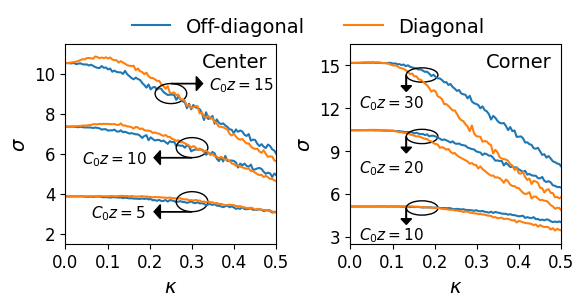

In [10]:
font_size = 14
tick_size = 12

C0 = 250
data_center = []
data_corner = []
for L1, L2 in zip([5, 10, 15], [10, 20, 30]):
    std_map_center = np.load(f'data/center_std_N=51,L={L1}C0,{C0=}.npy')
    std_map_corner = np.load(f'data/corner_std_N=51,L={L2}C0,{C0=}.npy')
    data_center.append(std_map_center)
    data_corner.append(std_map_corner)

kappa = np.linspace(0, 0.5, std_map_center.shape[0], True)

fig, axs = plt.subplots(1, 2, figsize=(6.4, 2.6))

for std_center, std_corner in zip(data_center, data_corner):
    axs[0].plot(kappa, std_center[:, 0], 'C0')
    axs[0].plot(kappa, std_center[0, :], 'C1')
    axs[1].plot(kappa, std_corner[:, 0], 'C0')
    axs[1].plot(kappa, std_corner[0, :], 'C1')

for ax in axs:
    ax.set_xlim(0, 0.5)
    ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.set_xlabel(r'$\kappa$', fontsize=font_size)
    ax.set_ylabel('$\\sigma$', fontsize=font_size)

axs[0].legend(['Off-diagonal', 'Diagonal'], fontsize=font_size, frameon=False, loc='lower center', bbox_to_anchor=(1.15, 0.95), ncol=3)

labels = ['Center', 'Corner']
for ax, label in zip(axs, labels):
    ax.text(0.8, 0.91, label, rotation=0, ha='center', va='center', transform=ax.transAxes, fontsize=font_size)

for y0 in [14.3, 10, 5]:
    arc0 = Arc((0.17, y0), width=0.075, height=1, angle=0, theta1=90, theta2=-90, color='black', fill=None, zorder=2)
    arc1 = Arc((0.17, y0), width=0.075, height=1, angle=0, theta1=-90, theta2=90, color='black', fill=None, zorder=1)
    axs[1].add_patch(arc0)
    axs[1].add_patch(arc1)
    axs[1].arrow(0.17 - 0.075/2, y0, 0, -0.75, head_width=0.025, head_length=0.4, fc='k')


axs[1].text(0.02, 12, '$C_0z=30$', fontsize=tick_size - 1)
axs[1].text(0.02, 7.5, '$C_0z=20$', fontsize=tick_size - 1)
axs[1].text(0.02, 2.8, '$C_0z=10$', fontsize=tick_size - 1)

axs[1].set_ylim(2.5, 16.5)

axs[1].set_yticks([3, 6, 9, 12, 15], [3, 6, 9, 12, 15])

for y0 in [6.3, 3.6]:
    arc0 = Arc((0.3, y0), width=0.075, height=1, angle=0, theta1=90, theta2=-90, color='black', fill=None, zorder=2)
    arc1 = Arc((0.3, y0), width=0.075, height=1, angle=0, theta1=-90, theta2=90, color='black', fill=None, zorder=1)
    axs[0].add_patch(arc0)
    axs[0].add_patch(arc1)
    axs[0].arrow(0.3, y0 - 0.5, -0.075, 0.0, head_width=0.7, head_length=0.015, fc='k')

arc0 = Arc((0.25, 9), width=0.075, height=1, angle=0, theta1=90, theta2=-90, color='black', fill=None, zorder=2)
arc1 = Arc((0.25, 9), width=0.075, height=1, angle=0, theta1=-90, theta2=90, color='black', fill=None, zorder=1)
axs[0].add_patch(arc0)
axs[0].add_patch(arc1)
axs[0].arrow(0.25, 9 + 0.5, 0.06, 0.0, head_width=0.7, head_length=0.015, fc='k')

axs[0].text(0.34, 9.2, '$C_0z=15$', fontsize=tick_size - 1)
axs[0].text(0.04, 5.5, '$C_0z=10$', fontsize=tick_size - 1)
axs[0].text(0.06, 2.8, '$C_0z=5$', fontsize=tick_size - 1)

axs[0].set_ylim(1.5, 11.5)

fig.subplots_adjust(wspace=0.35)
plt.show()

## End Matter Figures

### Small propagation

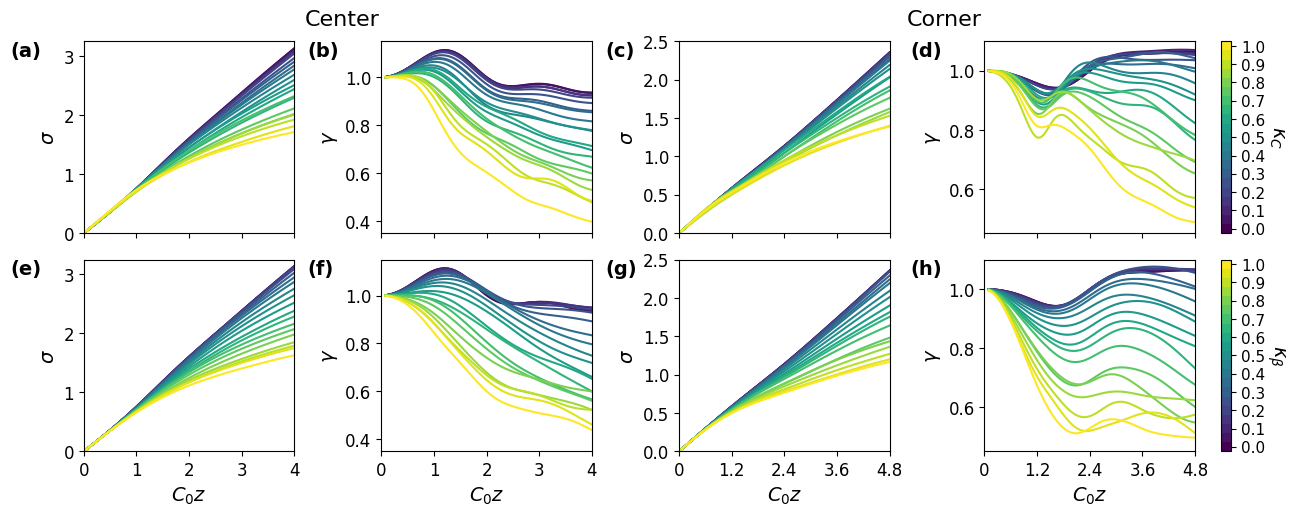

In [104]:
font_size = 14
tick_size = 12

data = np.load(f'data/center_N=51,L=4C0.npy')
std_data = data[0]
std_der_data = data[1]

data_c = np.load(f'data/corner_N=51,L=5C0.npy')
std_data_c = data_c[0]
std_der_data_c = data_c[1]

points = 100
C0 = 250
kappa_list = np.linspace(0, 1, std_der_data.shape[0])
num_lines = len(kappa_list)

# Colormap
cmap = get_cmap('viridis')
colors = [cmap(i / (num_lines - 1)) for i in range(num_lines)]

# Create figure with constrained layout
fig = plt.figure(figsize=(12.8, 4.8), constrained_layout=True)
gs = gridspec.GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)

# Axes
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
cax0 = fig.add_subplot(gs[0, 4])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
cax1 = fig.add_subplot(gs[1, 4])
axes = [ax00, ax01, ax10, ax11]
caxes = [cax0, cax1]

ax00c = fig.add_subplot(gs[0, 2])
ax01c = fig.add_subplot(gs[0, 3])
ax10c = fig.add_subplot(gs[1, 2])
ax11c = fig.add_subplot(gs[1, 3])
axesc = [ax00c, ax01c, ax10c, ax11c]

# Plots
L = 4 / C0
z = np.linspace(0, L, points)
for i, (kappa, color) in enumerate(zip(kappa_list, colors)):
    ax00.plot(C0 * z, std_data[i, 0], color=color, label=f'{kappa:.2f}')
    ax01.plot(C0 * z, std_der_data[i, 0], color=color)

for i, (kappa, color) in enumerate(zip(kappa_list, colors)):
    ax10.plot(C0 * z, std_data[0, i], color=color, label=f'{kappa:.2f}')
    ax11.plot(C0 * z, std_der_data[0, i], color=color)

L = 4.8 / C0
z = np.linspace(0, L, points)
for i, (kappa, color) in enumerate(zip(kappa_list, colors)):
    ax00c.plot(C0 * z, std_data_c[i, 0], color=color, label=f'{kappa:.2f}')
    ax01c.plot(C0 * z, std_der_data_c[i, 0], color=color)

for i, (kappa, color) in enumerate(zip(kappa_list, colors)):
    ax10c.plot(C0 * z, std_data_c[0, i], color=color, label=f'{kappa:.2f}')
    ax11c.plot(C0 * z, std_der_data_c[0, i], color=color)

# Colorbar
bounds = np.linspace(0, 1, num_lines + 1)
centers = (bounds[:-1] + bounds[1:]) / 2
norm = BoundaryNorm(boundaries=bounds, ncolors=num_lines)

# Select every other tick (show ~half)
center_ticks = centers[::2]
tick_labels = [f'{k:.1f}' for k in kappa_list[::2]]

# Create colorbar
cbar_labels = [r'$\kappa_C$', r'$\kappa_\beta$']
for cax, label in zip(caxes, cbar_labels):
    cbar = colorbar.ColorbarBase(cax, cmap=ListedColormap(colors), norm=norm,
                                 boundaries=bounds, ticks=center_ticks,
                                 spacing='proportional', orientation='vertical')
    cbar.set_label(label, fontsize=font_size, rotation=-90, labelpad=15)
    cbar.ax.set_yticklabels(tick_labels, fontsize=tick_size-1)
    cbar.ax.tick_params(which='minor', length=0)

# Axes formatting
ticks = [0, 1, 2, 3, 4]
for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.set_xlim(ticks[0], ticks[-1])
ax10.set_xlabel('$C_0 z$', fontsize=font_size)
ax11.set_xlabel('$C_0 z$', fontsize=font_size)
ax10.set_xticks(ticks, ticks)
ax11.set_xticks(ticks, ticks)
ax00.set_xticks(ticks, []*len(ticks))
ax01.set_xticks(ticks, []*len(ticks))

ax00.set_ylabel('$\\sigma$', fontsize=font_size)
ax10.set_ylabel('$\\sigma$', fontsize=font_size)
ax01.set_ylabel('$\\gamma$', fontsize=font_size)
ax11.set_ylabel('$\\gamma$', fontsize=font_size)

for ax in [ax00, ax10]: ax.set_ylim(0, 3.25)
for ax in [ax01, ax11]: ax.set_ylim(0.35, 1.15)
#############
ticks = [0, 1.2, 2.4, 3.6, 4.8]
for ax in axesc:
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.set_xlim(ticks[0], ticks[-1])
ax10c.set_xlabel('$C_0 z$', fontsize=font_size)
ax11c.set_xlabel('$C_0 z$', fontsize=font_size)
ax10c.set_xticks(ticks, ticks)
ax11c.set_xticks(ticks, ticks)
ax00c.set_xticks(ticks, []*len(ticks))
ax01c.set_xticks(ticks, []*len(ticks))

ax00c.set_ylabel('$\\sigma$', fontsize=font_size)
ax10c.set_ylabel('$\\sigma$', fontsize=font_size)
ax01c.set_ylabel('$\\gamma$', fontsize=font_size)
ax11c.set_ylabel('$\\gamma$', fontsize=font_size)

for ax in [ax00c, ax10c]: ax.set_ylim(0, 2.5)
for ax in [ax01c, ax11c]: ax.set_ylim(0.45, 1.1)

letters = ['(a)', '(b)', '(e)', '(f)']
for ax, letter in zip(axes, letters):
  ax.text(-0.35, 1, letter, transform=ax.transAxes, fontsize=font_size, fontweight='bold', va='top')

letters = ['(c)', '(d)', '(g)', '(h)']
for ax, letter in zip(axesc, letters):
  ax.text(-0.35, 1, letter, transform=ax.transAxes, fontsize=font_size, fontweight='bold', va='top')

fig.text(0.23, 1.01, 'Center', fontsize=font_size+2)
fig.text(0.7, 1.01, 'Corner', fontsize=font_size+2)

fig.savefig(f'figures/Figure_6.pdf', dpi=300, bbox_inches = "tight")
plt.show()

### Large propagation

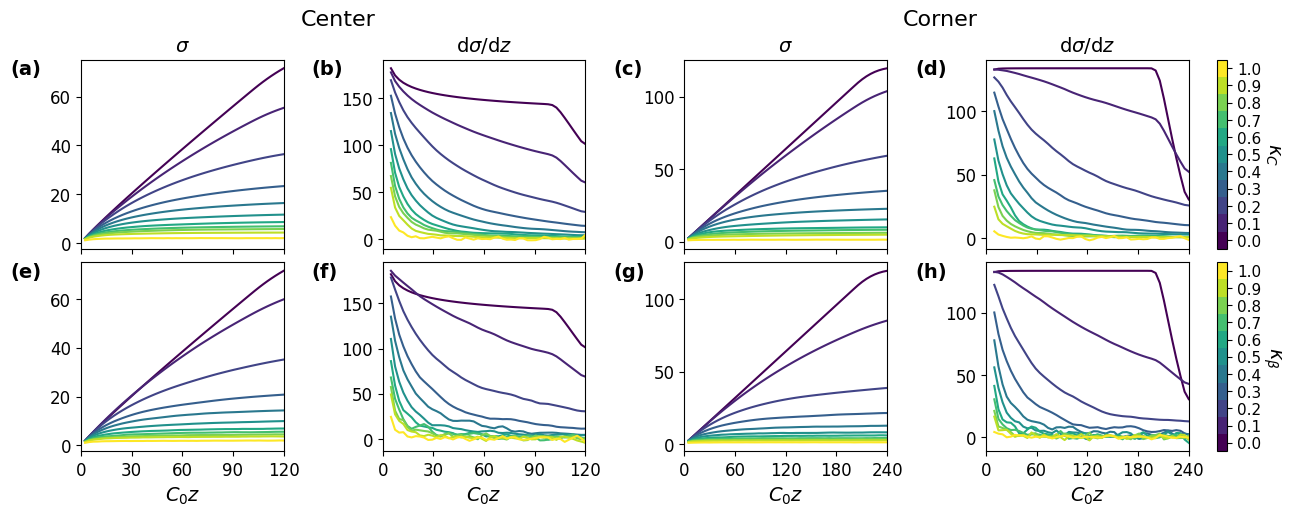

In [9]:
font_size = 14
tick_size = 12

std_off = np.load('data/center_c_N=401,L=120C0.npy')
std_diag = np.load('data/center_b_N=401,L=120C0.npy')
std_data_off = std_off[0]
std_data_diag = std_diag[0]

std_off_c = np.load('data/corner_c_N=401,L=240C0.npy')
std_diag_c = np.load('data/corner_b_N=401,L=240C0.npy')
std_data_off_c = std_off_c[0]
std_data_diag_c = std_diag_c[0]

points = std_data_off.shape[-1]
C0 = 250
kappa_list = np.linspace(0, 1, std_data_off.shape[0], endpoint=True)
num_lines = len(kappa_list)

# Colormap
cmap = get_cmap('viridis')
colors = [cmap(i / (num_lines - 1)) for i in range(num_lines)]

# Create figure with constrained layout
fig = plt.figure(figsize=(12.8, 4.8), constrained_layout=True)
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.05)

# Axes
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
cax0 = fig.add_subplot(gs[0, 4])

ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
cax1 = fig.add_subplot(gs[1, 4])

axes = [ax00, ax01, ax10, ax11]

ax00_c = fig.add_subplot(gs[0, 2])
ax01_c = fig.add_subplot(gs[0, 3])

ax10_c = fig.add_subplot(gs[1, 2])
ax11_c = fig.add_subplot(gs[1, 3])

axes_c = [ax00_c, ax01_c, ax10_c, ax11_c]

# Plots
L = 120 / C0
z = np.linspace(0, L, points)
for i, (kappa, color) in enumerate(zip(kappa_list, colors)):
    ax00.plot(C0 * z, std_data_off[i], color=color, label=f'{kappa:.2f}')
    ax01.plot(C0 * z, np.gradient(std_data_off[i], z), color=color)
    ax10.plot(C0 * z, std_data_diag[i], color=color, label=f'{kappa:.2f}')
    ax11.plot(C0 * z, np.gradient(std_data_diag[i], z), color=color)

L = 240 / C0
z = np.linspace(0, L, points)
for i, (kappa, color) in enumerate(zip(kappa_list, colors)):
    ax00_c.plot(C0 * z, std_data_off_c[i], color=color, label=f'{kappa:.2f}')
    ax01_c.plot(C0 * z, np.gradient(std_data_off_c[i], z), color=color)
    ax10_c.plot(C0 * z, std_data_diag_c[i], color=color, label=f'{kappa:.2f}')
    ax11_c.plot(C0 * z, np.gradient(std_data_diag_c[i], z), color=color)

# Colorbar
bounds = np.linspace(0, 1, num_lines + 1)
centers = (bounds[:-1] + bounds[1:]) / 2
norm = BoundaryNorm(boundaries=bounds, ncolors=num_lines)

# Select every other tick (show ~half)
center_ticks = centers
tick_labels = [f'{k:.1f}' for k in kappa_list]

# Create colorbar
cbar = colorbar.ColorbarBase(cax0, cmap=ListedColormap(colors), norm=norm,
                             boundaries=bounds, ticks=center_ticks,
                             spacing='proportional', orientation='vertical')
cbar.set_label(r'$\kappa_C$', fontsize=font_size, rotation=-90, labelpad=15)
cbar.ax.set_yticklabels(tick_labels, fontsize=tick_size-1)
cbar.ax.tick_params(which='minor', length=0)

cbar = colorbar.ColorbarBase(cax1, cmap=ListedColormap(colors), norm=norm,
                             boundaries=bounds, ticks=center_ticks,
                             spacing='proportional', orientation='vertical')
cbar.set_label(r'$\kappa_\beta$', fontsize=font_size, rotation=-90, labelpad=15)
cbar.ax.set_yticklabels(tick_labels, fontsize=tick_size-1)
cbar.ax.tick_params(which='minor', length=0)

# Axes formatting
_ = [0, 30, 60, 90, 120]
for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.set_xlim(_[0], _[-1])
ax00.set_xticks(_, []*5)
ax01.set_xticks(_, []*5)
ax10.set_xticks(_, _)
ax11.set_xticks(_, _)
ax10.set_xlabel('$C_0 z$', fontsize=font_size)
ax11.set_xlabel('$C_0 z$', fontsize=font_size)
ax00.set_title('$\\sigma$', fontsize=font_size)
ax01.set_title('d$\\sigma/$d$z$', fontsize=font_size)

_ = [0, 60, 120, 180, 240]
for ax in axes_c:
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.set_xlim(_[0], _[-1])
ax00_c.set_xticks(_, []*5)
ax01_c.set_xticks(_, []*5)
ax10_c.set_xticks(_, _)
ax11_c.set_xticks(_, _)
ax10_c.set_xlabel('$C_0 z$', fontsize=font_size)
ax11_c.set_xlabel('$C_0 z$', fontsize=font_size)
ax00_c.set_title('$\\sigma$', fontsize=font_size)
ax01_c.set_title('d$\\sigma/$d$z$', fontsize=font_size)

letters = ['(a)', '(b)', '(e)', '(f)']
for ax, letter in zip(axes, letters):
  ax.text(-0.35, 1, letter, transform=ax.transAxes, fontsize=font_size, fontweight='bold', va='top')

letters = ['(c)', '(d)', '(g)', '(h)']
for ax, letter in zip(axes_c, letters):
  ax.text(-0.35, 1, letter, transform=ax.transAxes, fontsize=font_size, fontweight='bold', va='top')

fig.text(0.23, 1.01, 'Center', fontsize=font_size+2)
fig.text(0.7, 1.01, 'Corner', fontsize=font_size+2)

fig.savefig(f'figures/Figure_7.pdf', dpi=300, bbox_inches = "tight")
plt.show()

## Data generation

### Center pump

In [ ]:
N = 51                         # dimension of array
points = 100                   # number of points to simulate
C0 = 250                       # linear coupling constant
g = 70                         # nonlinear constant
alpha = np.sqrt(0.0005)        # magnitud of pump field
beta_s = 7.85e6                # propagation constant for signal photons
f_0 = np.ones(N - 1)           # coupling profile
L = 4 / C0                     # propagation distance
z = np.linspace(0, L, points)
max_c = 0.9 * C0
max_b = 3 * C0
n_runs = 200
data = disorder_data(N, C0, g, alpha, beta_s, L, f_0, max_c, max_b, c_points=21, b_points=21, z_points=100, n_runs=n_runs)
np.save(f'data/center_{N=},L={L*C0:.0f}C0,{C0=}.npy', data)
print('Run successfully')

In [ ]:
N = 51                         # dimension of array
points = 100                   # number of points to simulate
C0 = 250                       # linear coupling constant
g = 70                         # nonlinear constant
alpha = np.sqrt(0.0005)        # magnitud of pump field
beta_s = 7.85e6                # propagation constant for signal photons
f_0 = np.ones(N - 1)           # coupling profile
L = 15 / C0                     # propagation distance
z = np.linspace(0, L, points)
max_c = 0.9 * C0
max_b = 3 * C0
n_runs = 200
data = disorder_data(N, C0, g, alpha, beta_s, L, f_0, max_c, max_b, c_points=100, b_points=100, z_points=1, n_runs=n_runs, max_kappa=0.5)
np.save(f'data/center_std_{N=},L={L*C0:.0f}C0,{C0=}.npy', data)
print('Run successfully')

### Corner pump

In [ ]:
N = 51                         # dimension of array
points = 100                   # number of points to simulate
C0 = 250                       # linear coupling constant
g = 70                         # nonlinear constant
alpha = np.sqrt(0.0005)        # magnitud of pump field
beta_s = 7.85e6                # propagation constant for signal photons
f_0 = np.ones(N - 1)           # coupling profile
L = 4.8 / C0                     # propagation distance
z = np.linspace(0, L, points)
max_c = 0.9 * C0
max_b = 3 * C0
n_runs = 200
data = disorder_data(N, C0, g, alpha, beta_s, L, f_0, max_c, max_b, c_points=21, b_points=21, z_points=100, n_runs=n_runs, pump_waveguide=1)
np.save(f'data/corner_{N=},L={L*C0:.0f}C0,{C0=}.npy', data)
print('Run successfully')

In [ ]:
N = 51                         # dimension of array
points = 100                   # number of points to simulate
C0 = 250                       # linear coupling constant
g = 70                         # nonlinear constant
alpha = np.sqrt(0.0005)        # magnitud of pump field
beta_s = 7.85e6                # propagation constant for signal photons
f_0 = np.ones(N - 1)           # coupling profile
L = 30 / C0                     # propagation distance
z = np.linspace(0, L, points)
max_c = 0.9 * C0
max_b = 3 * C0
n_runs = 200
data = disorder_data(N, C0, g, alpha, beta_s, L, f_0, max_c, max_b, c_points=100, b_points=100, z_points=1, n_runs=n_runs, max_kappa=0.5, pump_waveguide=1)
np.save(f'data/corner_std_{N=},L={L*C0:.0f}C0,{C0=}.npy', data)
print('Run successfully')